# 1. Download the dataset

Allan Schneider, Anna Krey, & Xinyi Tang

The dataset our group works on is an in-lab dataset, and we've uploaded our dataset to OSF: https://osf.io/5rp38/overview

There are five participant's data in the dataset. Each participant has one session of data, including T1-weighted anatomical scan and 3 runs of BOLD data of a task named as 'emfl' (Efficient Multifunctional fMRI localizer, Marvi et al., 2025). Each BOLD run has a corresponding _events.tsv file that contains the timing information of the experimental conditions (i.e., face, object, scene, letter, body, fixation).

Ref: Marvi, A. I., Hutchinson, S., Fedorenko, E., Saxe, R. R., Kamps, F. S., Regev, T. I., ... & Kanwisher, N. G. (2025). An efficient multifunction fMRI localizer for high-level visual, auditory, and cognitive regions in humans. Imaging Neuroscience, 3, IMAG-a.

Before running the script, please create a directory named as 'final_project_A' in your home directory or use the following bash command to create the folder:

In [1]:
%%bash

#create output directory
mkdir -p /home/jovyan/final_project_A

After creating the directory folder 'final_project_A', put this jupyter notebook file in the 'final_project_A' folder. Then, you can run the following scripts inside the 'final_project_A' folder.

In [ ]:
%%bash

cd /home/jovyan/final_project_A

#download the dataset from OSF, this might take a few minutes
osf -p 5rp38 clone .

#after downloading, move the data_scofi_fMRI_course folder to current directory
mv osfstorage/data_scofi_fMRI_course data_scofi_fMRI_course/

#delete the osfstorage folder
rmdir osfstorage

# 2. fMRIPrep preprocessing for a list of participants

The next cell runs fMRIPrep for a list of participants within one loop and writes the outputs under ~/data_scofi_fMRI_course/derivatives/.

### 2.1 Prepare FreeSurfer license file

Skip this step if you already have the FreeSurfe license. Otherwise, you can get the license from: https://surfer.nmr.mgh.harvard.edu/registration.html

After downloading the license file, please put the liscene file in the home directory (i.e., /home/jovyan/) then copy and paste the file to ~/.license.

In [ ]:
%%bash

#copy and paste the license file to ~/.license, this is required for running fMRIPrep
cp -f /home/jovyan/license.txt ~/.license

Run the following code to check whether the FreeSurfer license file exists at ~/.license

In [2]:
%%bash

#check whether fsl license exists
ls -l ~/.license

-rw-rw---- 1 jovyan users 109 Feb 12 19:51 /home/jovyan/.license


### 2.2 Preprocessing with fMRIPrep


**Notes:**

1. We run fMRIPrep without surface reconstruction (`--fs-no-reconall`) and use MNI152NLin6Asym (`MNI152NLin6Asym`) as the standard output space.  

2. This command may take several hours to complete, especially when processing all five participants. To check whether it is still running, open the Terminal and type `top`. The `antsRegistration` step is particularly slow, so extended periods of apparent inactivity are expected.

In [ ]:
%%bash

#load fmriprep
source /etc/profile
module load fmriprep/25.1.3

DATASET_ROOT="/home/jovyan/final_project_A/data_scofi_fMRI_course"
DERIVATIVES_ROOT="${DATASET_ROOT}/derivatives"
WORK_ROOT="/home/jovyan/final_project_A/fmriprep_work" #working directory should be outside BIDS dataset
FS_LICENSE="${HOME}/.license"

#make output directories
mkdir -p "${DERIVATIVES_ROOT}"
mkdir -p "${WORK_ROOT}"

subjects=("1001" "1002" "1003" "1004" "1005") # or "1001" for just one subject

for sub in "${subjects[@]}"; do
    sub_work="${WORK_ROOT}/${sub}"
    mkdir -p "${sub_work}"

    echo
    echo "Running subject ${sub}"

    fmriprep "${DATASET_ROOT}" "${DERIVATIVES_ROOT}" participant \
        --participant-label "${sub}" \
        --fs-no-reconall \
        --output-spaces MNI152NLin6Asym \
        --fs-license-file "${FS_LICENSE}" \
        -w "${sub_work}" \
        --nthreads 14 \
        --omp-nthreads 2 \
        --mem 24000
done

### 2.3 Check outputs of fMRIPrep

When fMRIPrep finishes, the files most relevant for first-level analysis are:

1. **HTML report**  
   (e.g., `derivatives/sub-1001.html`)

2. **Preprocessed T1w image in MNI space**  
   (e.g., `derivatives/sub-1001/ses-01/anat/sub-1001_ses-01_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz`)

3. **Preprocessed BOLD file in MNI space**  
   (e.g., `derivatives/sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-01_space-MNI152NLin6Asym_desc-preproc_bold.nii.gz`)

4. **Confounds files**  
   (e.g., `derivatives/sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-01_desc-confounds_timeseries.tsv`)

> **Note:**  
> For the sake of time, we have already run fMRIPrep for all five participants and uploaded the preprocessed results for two participants (`sub-1001`, `sub-1002`) along with the original data. You can find them under `~/data_scofi_fMRI_course/derivatives/`.  
>
> The following code checks whether the above files exist for each participant and prints their relative paths. If you did not run fMRIPrep for all participants, you should expect output for `sub-1001` and `sub-1002`, but not for the others.

In [2]:
from pathlib import Path

root = Path("data_scofi_fMRI_course/derivatives")
subjects = ["1001", "1002", "1003", "1004", "1005"]

for s in subjects:
    sub = f"sub-{s}"
    sub_dir = root / sub

    print(f"\n===== {sub} =====")

    # 1. HTML file (top level)
    html_file = root / f"{sub}.html"
    print("[HTML]")
    if html_file.exists():
        print(html_file.relative_to(root))
    else:
        print("None")

    # 2. T1w image
    print("[T1w image (MNI space)]")
    T1_files = sorted(list(sub_dir.glob(f"**/{sub}_*MNI152NLin6Asym_desc-preproc_T1w.nii.gz")))
    if T1_files:
        for f in T1_files:
            print(f.relative_to(root))
    else:
        print("None")

    # 3. fMRIPrep preprocessed bold
    print("[PREPROC BOLD]")
    preproc_files = sorted(list(sub_dir.glob(f"**/{sub}_*task-emfl*run-*desc-preproc_bold.nii.gz")))
    if preproc_files:
        for f in preproc_files:
            print(f.relative_to(root))
    else:
        print("None")

    # 4. confounds
    print("[CONFOUNDS TSV]")
    confound_files = sorted(list(sub_dir.glob(f"**/{sub}_*task-emfl*run-*desc-confounds_timeseries.tsv")))
    if confound_files:
        for f in confound_files:
            print(f.relative_to(root))
    else:
        print("None")


===== sub-1001 =====
[HTML]
sub-1001.html
[T1w image (MNI space)]
sub-1001/ses-01/anat/sub-1001_ses-01_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz
[PREPROC BOLD]
sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-01_space-MNI152NLin6Asym_desc-preproc_bold.nii.gz
sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-02_space-MNI152NLin6Asym_desc-preproc_bold.nii.gz
sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-03_space-MNI152NLin6Asym_desc-preproc_bold.nii.gz
[CONFOUNDS TSV]
sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-01_desc-confounds_timeseries.tsv
sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-02_desc-confounds_timeseries.tsv
sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-03_desc-confounds_timeseries.tsv

===== sub-1002 =====
[HTML]
sub-1002.html
[T1w image (MNI space)]
sub-1002/ses-01/anat/sub-1002_ses-01_space-MNI152NLin6Asym_desc-preproc_T1w.nii.gz
[PREPROC BOLD]
sub-1002/ses-01/func/sub-1002_ses-01_task-emfl_run-01_space-MNI152NLin6Asym_desc-preproc_bold.nii.g

# 3. Make a FEAT confounds file



We will loop through each subject and each run, read the confounds tsv file, select a subset of confounds that we want to use for FEAT, and then save the selected confounds in a new tsv file (without header and index) in a new folder named 'fsl' under derivatives. The new tsv file will be named as 'sub-1005_ses-01_task-emfl_run-01_desc-fslConfounds.tsv'.

We keep:

cosine regressors
non-steady-state regressors
6 motion parameters
the first 6 aCompCor components
framewise displacement, if it exists
FEAT wants a plain text file without a header, so we write the output that way.

This is a good example of why notebook workflows can be useful for teaching: you can see exactly which nuisance regressors are being kept, rather than hiding that logic inside a separate script.

In [3]:
import pandas as pd
#Define the Base Directory
base_dir = Path("/home/jovyan/final_project_A/data_scofi_fMRI_course")

# Define all the subjects, making sure to include the sub- prefix, and the runs that we want to process.
subjects = ["sub-1001", "sub-1002", "sub-1003", "sub-1004", "sub-1005"] # we have 5 subjects
runs = ["01", "02", "03"] # we have 3 runs for each subject

#Loop through Each subject
for subject in subjects:
    print(f"Beginning {subject}...") #
    for run in runs:
        print(f"Processing {subject}'s run {run}...")
        current_confounds_tsv = base_dir / "derivatives" / f"{subject}" / "ses-01" / "func" / f"{subject}_ses-01_task-emfl_run-{run}_desc-confounds_timeseries.tsv"
        confounds = pd.read_csv(current_confounds_tsv, sep="	")
        
        # Keep a simple but still realistic set of nuisance regressors.
        cosine_cols = [c for c in confounds.columns if c.startswith("cosine")]
        nss_cols = [c for c in confounds.columns if c.startswith("non_steady_state")]
        motion_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
        acompcor_cols = [c for c in confounds.columns if c.startswith("a_comp_cor_")][:6]
        fd_cols = ["framewise_displacement"] if "framewise_displacement" in confounds.columns else []
        
        keep_cols = cosine_cols + nss_cols + motion_cols + acompcor_cols + fd_cols
        feat_confounds = confounds[keep_cols].fillna(0)
        
        out_dir = base_dir / "derivatives" / "fsl" / "confounds" / f"{subject}"
        out_dir.mkdir(parents=True, exist_ok=True)
        
        out_file = out_dir / f"{subject}_ses-01_task-emfl_run-{run}_desc-fslConfounds.tsv"
        feat_confounds.to_csv(out_file, sep="	", header=False, index=False)
        
        print(out_file)
        print(feat_confounds.shape)
        feat_confounds.head()
        print(f"Finished {subject}'s run {run}!")
    

Beginning sub-1001...
Processing sub-1001's run 01...
/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/sub-1001/sub-1001_ses-01_task-emfl_run-01_desc-fslConfounds.tsv
(140, 16)
Finished sub-1001's run 01!
Processing sub-1001's run 02...
/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/sub-1001/sub-1001_ses-01_task-emfl_run-02_desc-fslConfounds.tsv
(140, 16)
Finished sub-1001's run 02!
Processing sub-1001's run 03...
/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/sub-1001/sub-1001_ses-01_task-emfl_run-03_desc-fslConfounds.tsv
(140, 16)
Finished sub-1001's run 03!
Beginning sub-1002...
Processing sub-1002's run 01...
/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/sub-1002/sub-1002_ses-01_task-emfl_run-01_desc-fslConfounds.tsv
(140, 17)
Finished sub-1002's run 01!
Processing sub-1002's run 02...
/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confound

In [4]:
import nibabel as nib

subject = "sub-1001"
run = "1"
core_path = "/home/jovyan/final_project_A/data_scofi_fMRI_course/"

bold_path = f"{core_path}/{subject}/ses-01/func/{subject}_ses-01_task-emfl_run-0{run}_bold.nii.gz"
confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/{subject}/{subject}_ses-01_task-emfl_run-0{run}_desc-fslConfounds.tsv"
confounds = pd.read_csv(confounds_path, sep="\t", header=None)

bold = nib.load(bold_path)
print(len(confounds), bold.shape[-1])


140 140


If they match up it confirms number of rows in confounds file matches the number of volumes

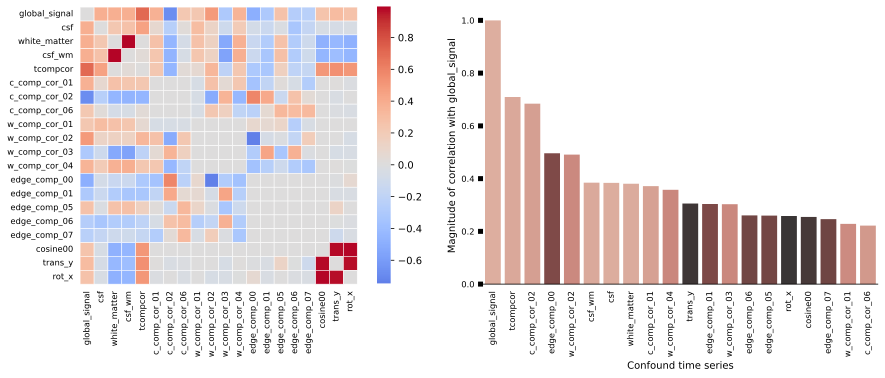

In [5]:
from IPython.display import SVG, display

# open svg file containing the correlation matrix
path = "/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/sub-1001/figures/sub-1001_ses-01_task-emfl_run-01_desc-confoundcorr_bold.svg"

display(SVG(filename=path))


1. A mix of warm and cool colors

   
Indicative of different confounds correlating differently with the BOLD signal — expected and healthy.


2. No giant uniform blocks of one color

   
This would suggest:

A. A confound that is constant over time, which is not useful for regression and could indicate a problem with the confound file.

B. A confound that is redundant with another confound, which could cause issues with multicollinearity in the regression model.

C. A confound that is incorrectly shaped (e.g., a single value repeated across all timepoints), which would not be meaningful for regression.

We can see lots of variation which is what we want.

3. No columns or rows that are all white/grey

This would suggest a confound has no relationship with the data, the confound is all zeros, or the shapes don’t match.

This plot shows non‑zero structure, so the confounds are applied correctly.

4. No extreme saturation across the entire matrix
   
If everything were bright red or bright blue, that would indicate, overfitting, a confound absorbing all variance, or a mistake in scaling.

This matrix displays a good balance and is in good shape.

## Visualise the Confounds files from feat and fmriprep

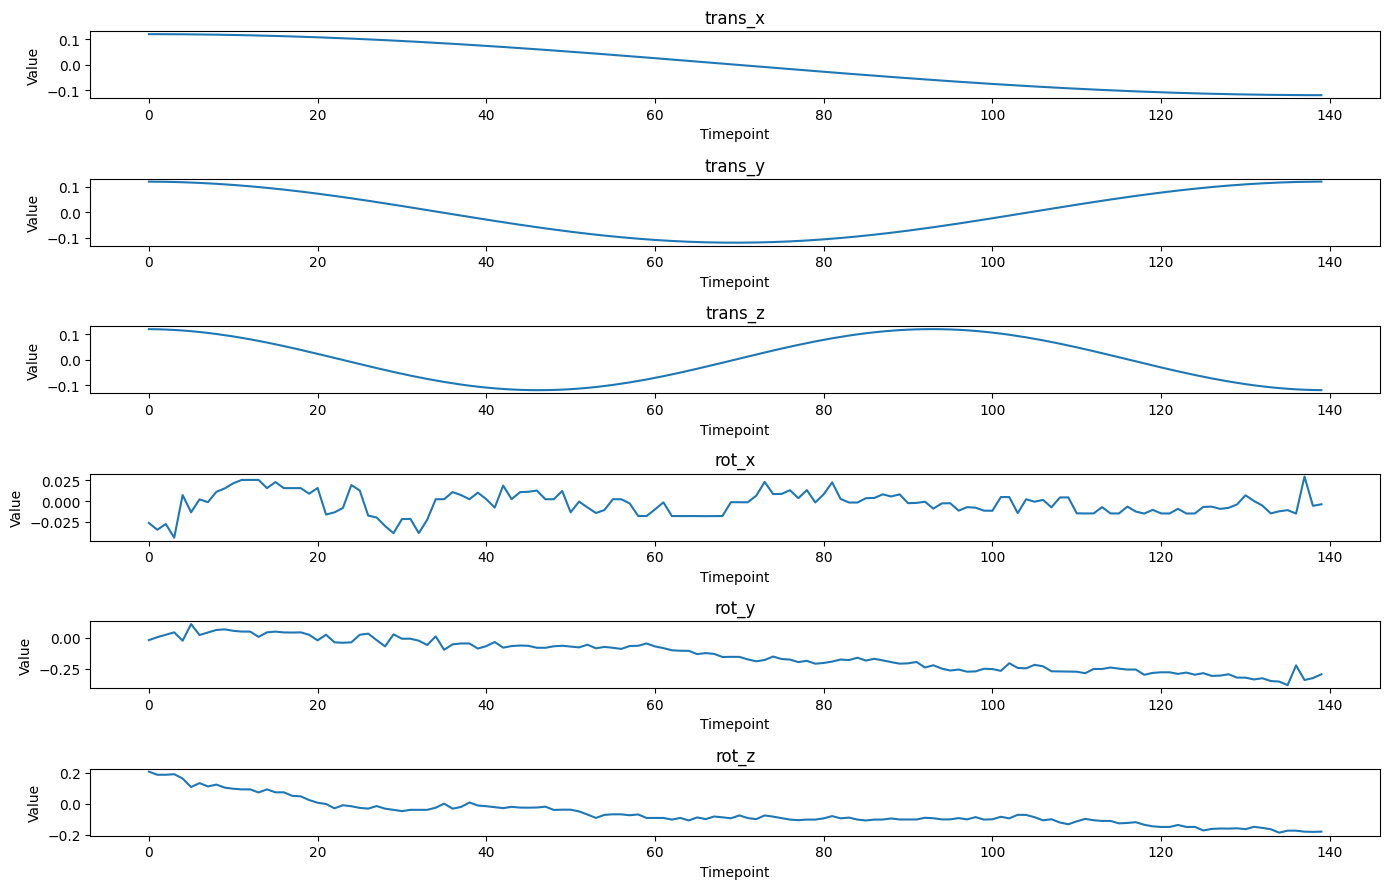

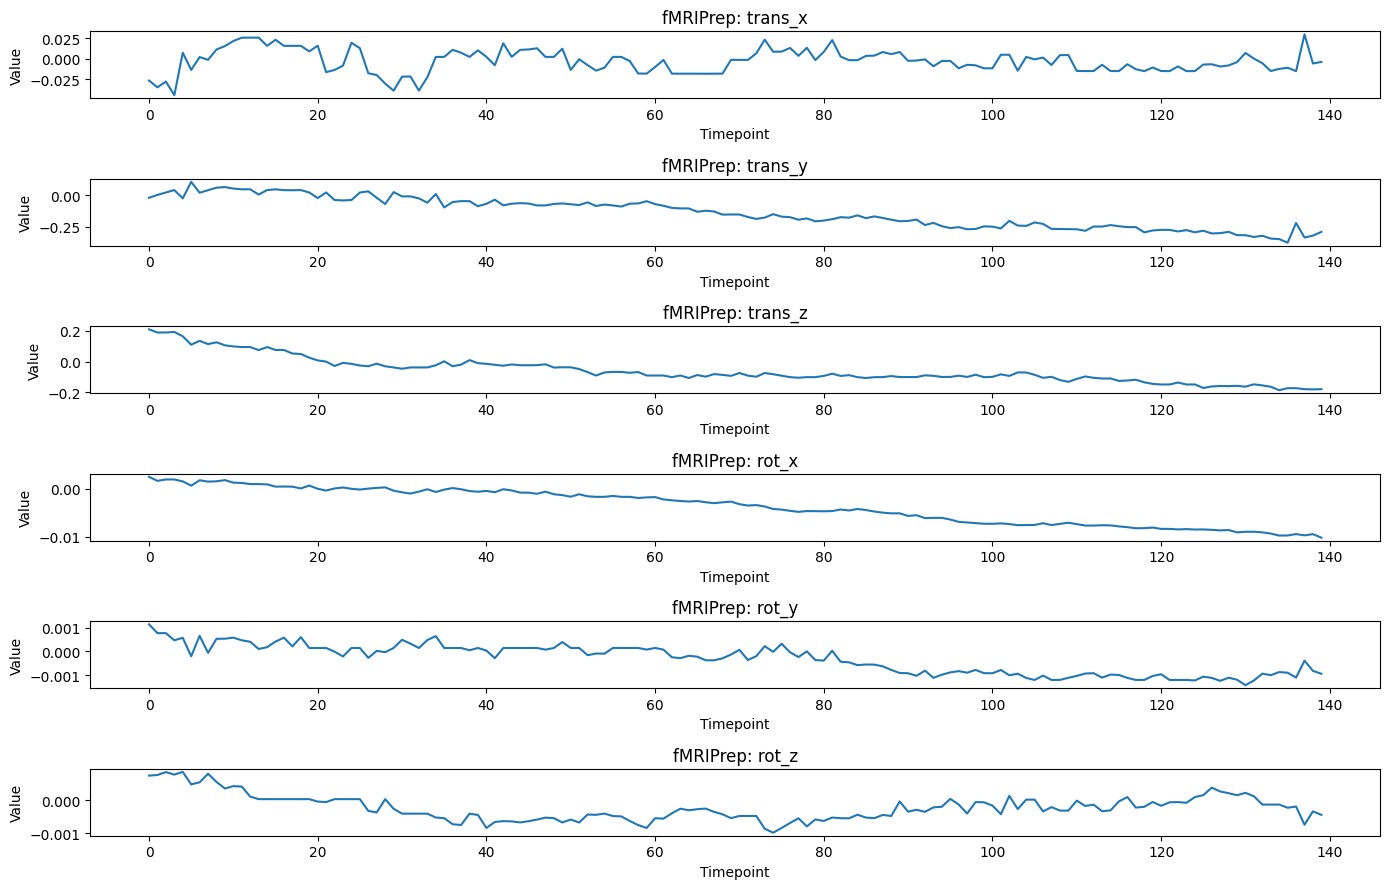

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
subject = "sub-1001"
run = "1"
confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/{subject}/{subject}_ses-01_task-emfl_run-0{run}_desc-fslConfounds.tsv"

# Load confounds
confounds = pd.read_csv(confounds_path, sep="\t", header=None)

# Define the expected motion columns (in order)
motion_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]

# Since your file has no header, assign column names
confounds.columns = motion_cols + [f"extra_{i}" for i in range(confounds.shape[1] - len(motion_cols))]

# Plot only the motion columns that exist
available_motion_cols = [col for col in motion_cols if col in confounds.columns]

if not available_motion_cols:
    print("No motion columns found!")
else:
    plt.figure(figsize=(14, len(available_motion_cols)*1.5))
    for i, col in enumerate(available_motion_cols):
        plt.subplot(len(available_motion_cols), 1, i+1)
        plt.plot(confounds[col])
        plt.title(col)
        plt.xlabel("Timepoint")
        plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# Path to fMRIPrep confounds file (adjust path as needed)
fmriprep_confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/{subject}/ses-01/func/{subject}_ses-01_task-emfl_run-0{run}_desc-confounds_timeseries.tsv"

# Load fMRIPrep confounds
fmriprep_confounds = pd.read_csv(fmriprep_confounds_path, sep="\t")

# Standard fMRIPrep motion columns
motion_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
available_motion_cols = [c for c in motion_cols if c in fmriprep_confounds.columns]

if not available_motion_cols:
    print("No motion columns found in fMRIPrep confounds!")
else:
    plt.figure(figsize=(14, len(available_motion_cols)*1.5))
    for i, col in enumerate(available_motion_cols):
        plt.subplot(len(available_motion_cols), 1, i+1)
        plt.plot(fmriprep_confounds[col])
        plt.title(f"fMRIPrep: {col}")
        plt.xlabel("Timepoint")
        plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

There are differences because the FEAT file is a transformed, reduced version of the fMRIPrep file, created specifically to satisfy constraints of Feat.

## Bold Signal and Confounds

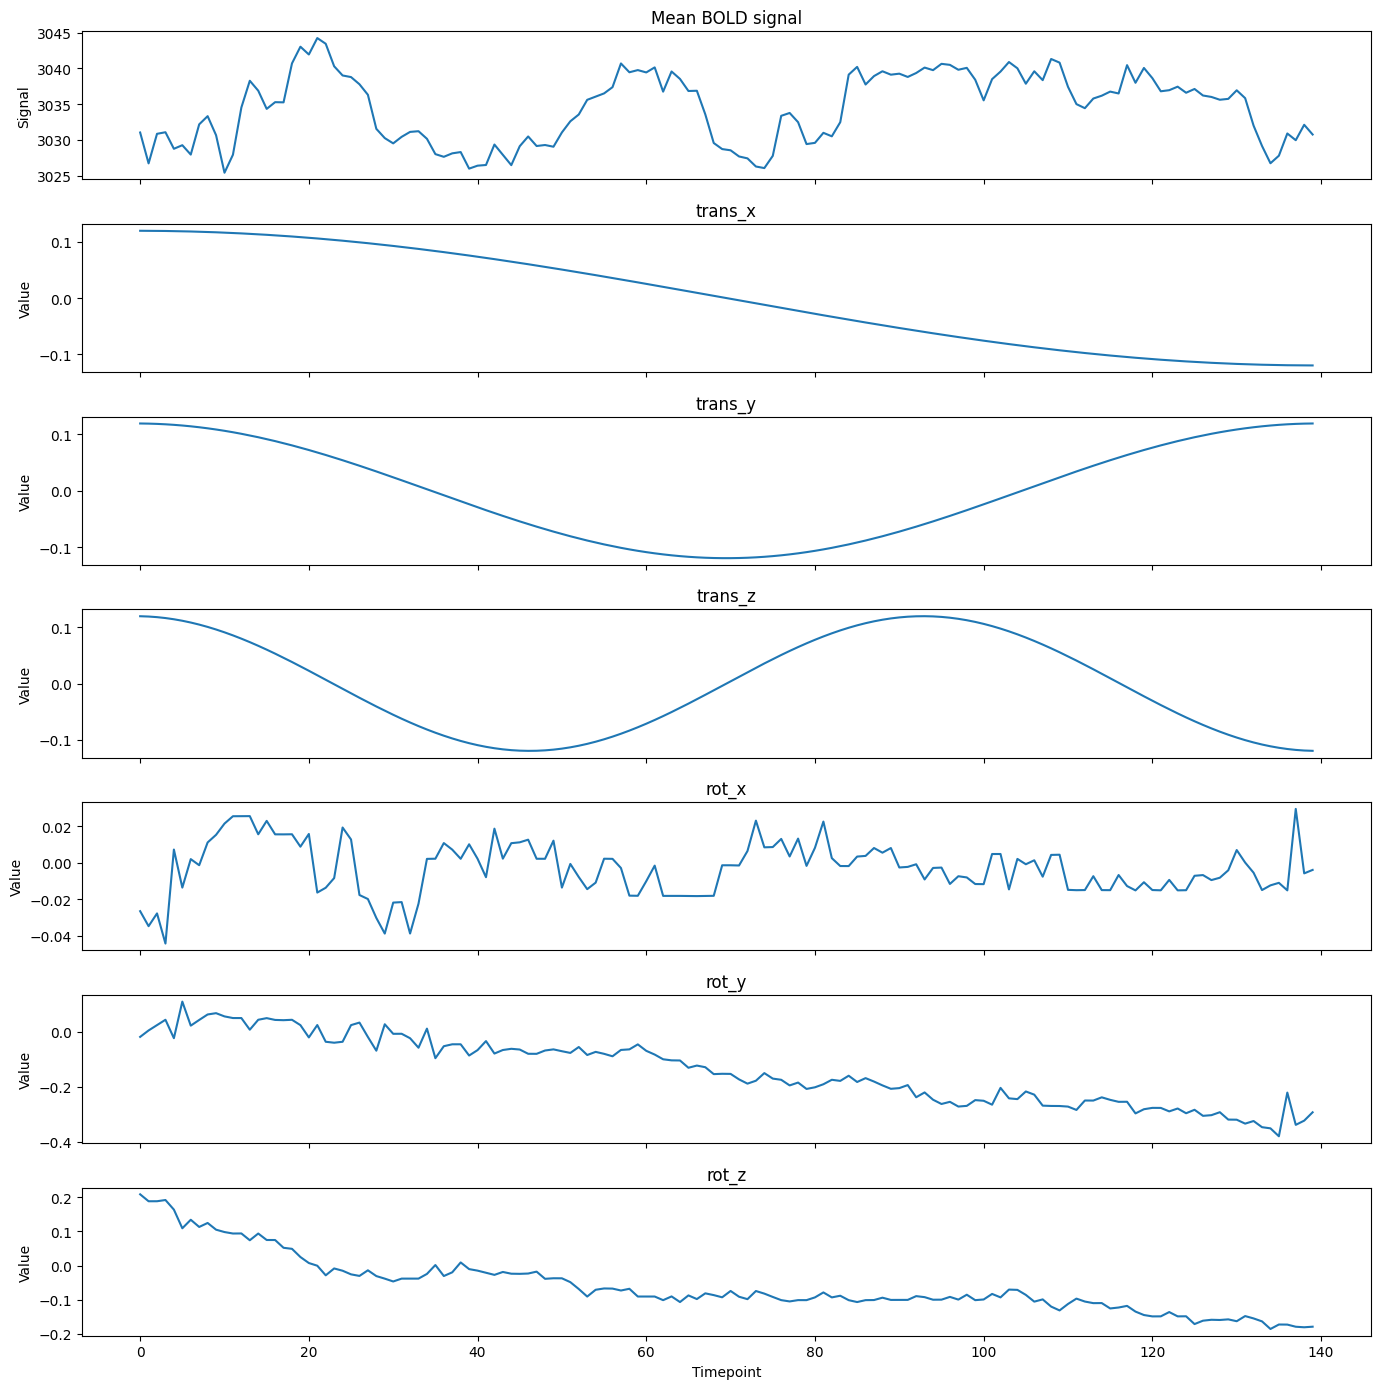

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

subject = "sub-1001"
run = "1"
confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/{subject}/{subject}_ses-01_task-emfl_run-0{run}_desc-fslConfounds.tsv"

core_path = "/home/jovyan/final_project_A/data_scofi_fMRI_course/"

# Load BOLD file (4D NIfTI)
bold_path = f"{core_path}/{subject}/ses-01/func/{subject}_ses-01_task-emfl_run-0{run}_bold.nii.gz"
img = nib.load(bold_path)
data = img.get_fdata()

# Compute mean BOLD signal across all voxels (or use a mask/ROI)
mean_bold = data.mean(axis=(0, 1, 2))

# Load FEAT confounds (no header)
confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/{subject}/{subject}_ses-01_task-emfl_run-0{run}_desc-fslConfounds.tsv"
motion_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
confounds = pd.read_csv(confounds_path, sep="\t", header=None)
confounds.columns = motion_cols + [f"extra_{i}" for i in range(confounds.shape[1] - len(motion_cols))]

# Plot mean BOLD and motion parameters
fig, axes = plt.subplots(len(motion_cols)+1, 1, figsize=(14, 2*(len(motion_cols)+1)), sharex=True)
axes[0].plot(mean_bold)
axes[0].set_title("Mean BOLD signal")
axes[0].set_ylabel("Signal")

for i, col in enumerate(motion_cols):
    axes[i+1].plot(confounds[col])
    axes[i+1].set_title(col)
    axes[i+1].set_ylabel("Value")

plt.xlabel("Timepoint")
plt.tight_layout()
plt.show()

### Let's visualise the design and counfound matrix of FEAT confounds file. 
This is a good way to check whether the confounds file looks as expected, and to see how the different regressors vary over time.


In [9]:
!pip install seaborn


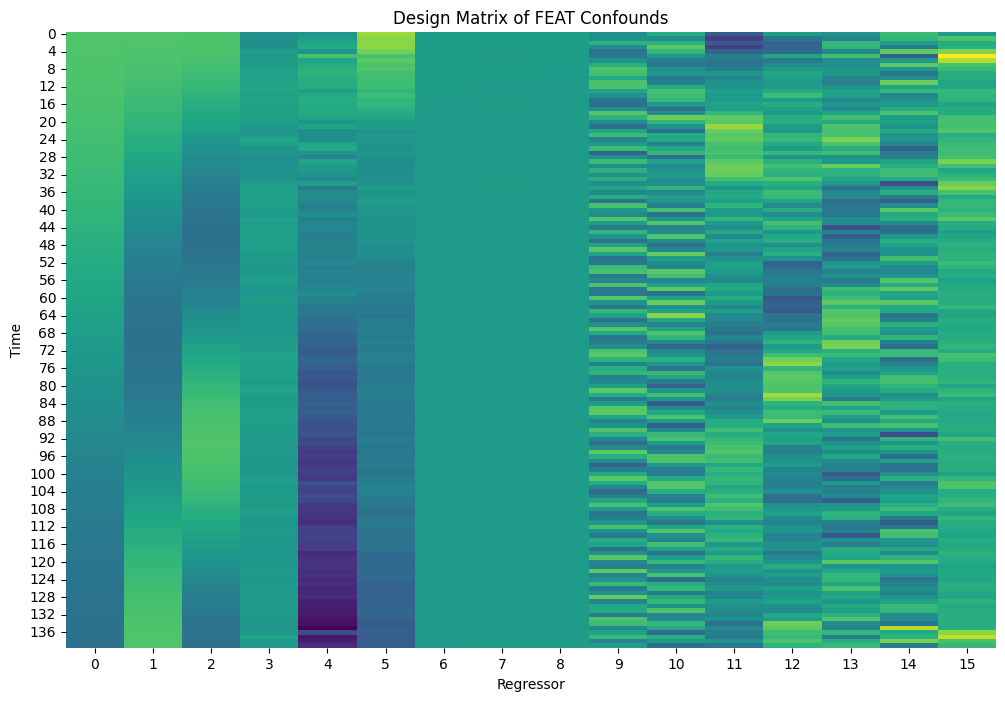

In [10]:
import seaborn as sns
subject = "sub-1001"
run = "1"
confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/{subject}/{subject}_ses-01_task-emfl_run-0{run}_desc-fslConfounds.tsv"
confounds = pd.read_csv(confounds_path, sep="\t", header=None)

plt.figure(figsize=(12,8))
sns.heatmap(confounds, cmap="viridis", cbar=False)
plt.title("Design Matrix of FEAT Confounds")
plt.xlabel("Regressor")
plt.ylabel("Time")
plt.show()


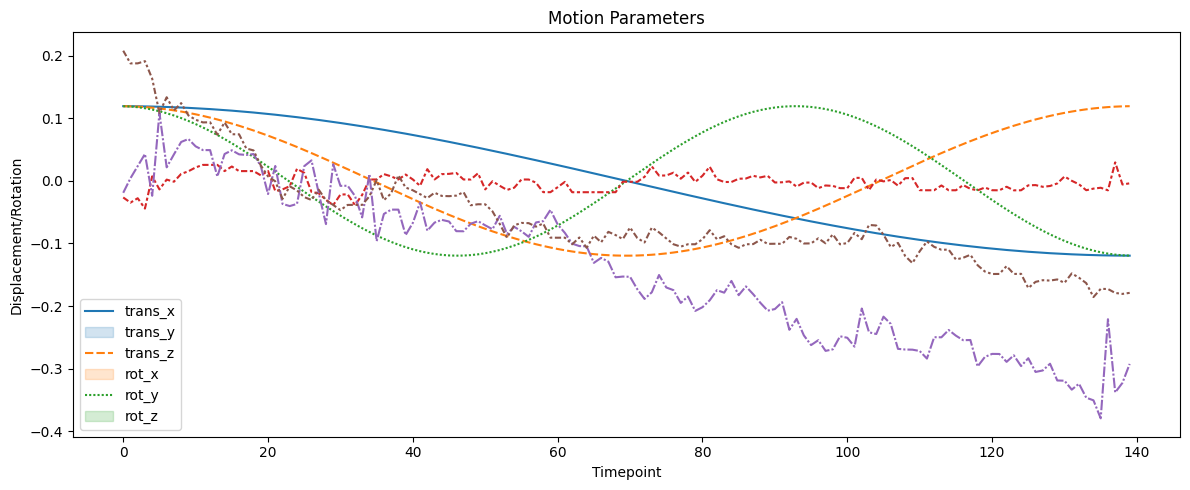

In [11]:
# Python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

subject = "sub-1001"
run = "1"
# Set up paths and parameters
confounds_path = f"/home/jovyan/final_project_A/data_scofi_fMRI_course/derivatives/fsl/confounds/{subject}/{subject}_ses-01_task-emfl_run-0{run}_desc-fslConfounds.tsv"

# Read confounds with no header
confounds = pd.read_csv(confounds_path, sep="\t", header=None)

# Assign column names: first 6 are motion
motion_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z"]
confounds.columns = motion_cols + [f"extra_{i}" for i in range(confounds.shape[1] - len(motion_cols))]

os.makedirs("qc", exist_ok=True)

# 1. Plot motion parameters
plt.figure(figsize=(12, 5))
sns.lineplot(data=confounds[motion_cols])
plt.title("Motion Parameters")
plt.xlabel("Timepoint")
plt.ylabel("Displacement/Rotation")
plt.legend(motion_cols)
plt.tight_layout()
plt.savefig("qc/motion_parameters.png", dpi=150)
plt.show()


What would be concerning:

1. if we saw huge spikes in the motion parameters, that would indicate a large head movement at that timepoint, which could cause significant artifacts in the data. 

2. Sudden discontinuities in the motion parameters, which could indicate a sudden movement or a problem with the motion correction.

3. Drifts that ramp up over time, which could indicate gradual head movement or scanner instability.

4. Rotations that explode or oscillate wildly, which could indicate severe head motion or a problem with the motion correction.

5. Flat lines in the motion parameters, which could indicate missing data or a problem with the motion correction.

6. If the motion parameters show a pattern that correlates with the experimental conditions, that could indicate that the participant was moving in response to the task, which could confound the results.



what do we see though:

1. Translations

-Small fluctuations around zero with occasional small jumps

-No extreme spikes are seen, or drift indicating scanner instability

2. Rotations

-We can see smooth, low‑amplitude oscillations in the rotation parameters, which is typical of normal head motion during a scan.

-No sudden jumps and overall is in the range of normal head motion in a task run.





# 4. Visualize events files 
## this allows us to check the design and structure of the events 


In [89]:
# load the file
import pandas as pd

events = pd.read_csv("data_scofi_fMRI_course/sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-01_events.tsv", sep="\t")
print(events.head())

       onset   duration trial_type
0   0.000277  17.996771   fixation
1  18.210391  22.003426       face
2  40.326435  22.003859      scene
3  62.442729  22.004580       body
4  84.578296  22.002946     object


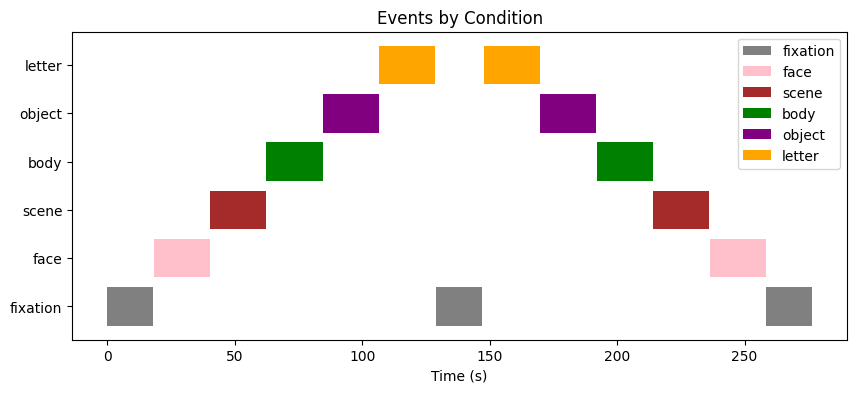

In [90]:
import matplotlib.pyplot as plt

#group by conditions 
conditions = events["trial_type"].unique()

color_map = {
    "face": "pink",
    "scene": "brown",
    "body": "green",
    "object": "purple",
    "letter": "orange",
    "fixation": "gray"
}

fig, ax = plt.subplots(figsize=(10, 4))

for i, cond in enumerate(conditions):
    subset = events[events["trial_type"] == cond]
    
    bars = [(row["onset"], row["duration"]) for _, row in subset.iterrows()]
    
    ax.broken_barh(
        bars,
        (i - 0.4, 0.8),
        facecolors=color_map[cond],   # key change
        label=cond
    )

ax.set_xlabel("Time (s)")
ax.set_yticks(range(len(conditions)))
ax.set_yticklabels(conditions)
ax.set_title("Events by Condition")
ax.legend()

plt.show()

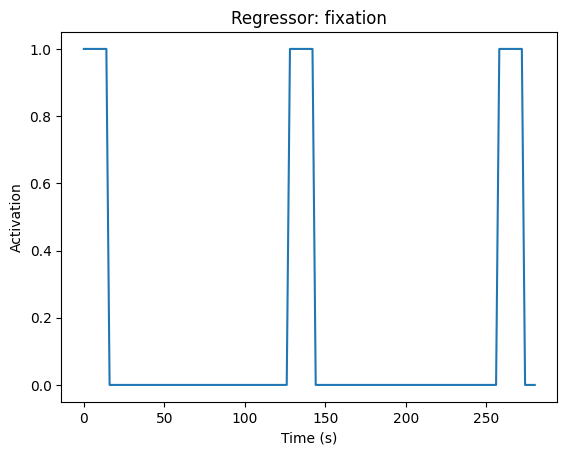

In [91]:
# view it as a binary time series version 

import numpy as np

TR = 2.0
total_time = events["onset"].max() + events["duration"].max()
timepoints = np.arange(0, total_time, TR)

design = {cond: np.zeros(len(timepoints)) for cond in conditions}

for _, row in events.iterrows():
    onset_idx = int(row["onset"] // TR)
    duration_idx = int(row["duration"] // TR)
    
    design[row["trial_type"]][onset_idx:onset_idx + duration_idx] = 1

# plot one condition
plt.plot(timepoints, design[conditions[0]])
plt.xlabel("Time (s)")
plt.ylabel("Activation")
plt.title(f"Regressor: {conditions[0]}")
plt.show()

### Now check, whether: 

Onsets align with scan timing

No overlaps if your design assumes separation

Durations are not zero unless intended

Trial counts per condition match your design

# 5. Creating 3-Column FSL file

## Helper functions

In [92]:
from IPython.display import Markdown, display
from pathlib import Path
import json
import os
import re
import subprocess
import shlex


HOME = Path.home()

DATASET_ROOT = Path(HOME/"final_project_A/data_scofi_fMRI_course")
SELECTED_SUBJECT = "sub-1001"
SELECTED_BOLD_BASENAME = f"{SELECTED_SUBJECT}_ses-01_task-emfl_run-01_bold.nii.gz"

DATASETS_HOME = HOME / "final_project_A"

DERIVATIVES_ROOT = DATASET_ROOT / "derivatives"
os.makedirs(DERIVATIVES_ROOT, exist_ok=True)

PREVIEW_ROOT = DERIVATIVES_ROOT / "previews"
os.makedirs(PREVIEW_ROOT, exist_ok=True)

THREECOL_ROOT = DERIVATIVES_ROOT / "fsl_3col"
os.makedirs(THREECOL_ROOT, exist_ok=True)

BIDSUTILS_ROOT = HOME / "bidsutils"
BIDSTO3COL_SCRIPT = BIDSUTILS_ROOT / "BIDSto3col" / "BIDSto3col.sh"

def run(cmd, cwd=None):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=True, cwd=cwd)

def parse_bids_entities(path):
    name = Path(path).name.replace("_events.tsv", "")
    entities = {}
    for token in name.split("_"):
        if "-" in token:
            key, value = token.split("-", 1)
            entities[key] = value
    return entities

def subject_from_path(path):
    path = Path(path)
    for part in path.parts:
        if re.fullmatch(r"sub-[A-Za-z0-9]+", part):
            return part
    match = re.search(r"(sub-[A-Za-z0-9]+)", path.name)
    return match.group(1) if match else "unknown-sub"

def quote(pathlike):
    return shlex.quote(str(pathlike))

print(DATASET_ROOT)

/home/jovyan/final_project_A/data_scofi_fMRI_course


In [93]:
if not BIDSUTILS_ROOT.exists():
    run(f"git clone https://github.com/bids-standard/bidsutils.git {quote(BIDSUTILS_ROOT)}", cwd=HOME)

if not BIDSTO3COL_SCRIPT.exists():
    raise FileNotFoundError(f"Cannot find {BIDSTO3COL_SCRIPT}")

threecol_records = []

#get events file
events_files = sorted(DATASET_ROOT.glob("sub-*/ses-01/func/*_events.tsv"))

if len(events_files) == 0:
    raise FileNotFoundError("No local _events.tsv files were found. The dataset install appears incomplete.")

for events_path in events_files:
    events_path = Path(events_path)
    subject = subject_from_path(events_path)
    entities = parse_bids_entities(events_path)
    task = entities.get("task", "")
    run_id = entities.get("run", "")
    entity_root = events_path.name.replace("_events.tsv", "")

    out_dir = THREECOL_ROOT / subject / "func"
    out_dir.mkdir(parents=True, exist_ok=True)

    # Remove older outputs for this run so rerunning the notebook stays tidy.
    for old_file in out_dir.glob(f"{entity_root}*.txt"):
        old_file.unlink()

    run(
        f"bash {quote(BIDSTO3COL_SCRIPT)} {quote(events_path)} {quote(entity_root)}",
        cwd=out_dir,
    )

    generated_files = sorted(out_dir.glob(f"{entity_root}*.txt"))
    for out_file in generated_files:
        condition = out_file.stem.replace(entity_root, "").lstrip("_-.")
        threecol_records.append(
            {
                "subject": subject,
                "task": task,
                "run": run_id,
                "events_tsv": str(events_path.relative_to(DATASET_ROOT)),
                "condition": condition or "all",
                "three_col_file": str(out_file.relative_to(DATASET_ROOT)),
            }
        )

$ bash /home/jovyan/bidsutils/BIDSto3col/BIDSto3col.sh /home/jovyan/final_project_A/data_scofi_fMRI_course/sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-01_events.tsv sub-1001_ses-01_task-emfl_run-01
Creating 'sub-1001_ses-01_task-emfl_run-01_body.txt'
Creating 'sub-1001_ses-01_task-emfl_run-01_face.txt'
Creating 'sub-1001_ses-01_task-emfl_run-01_fixation.txt'
Creating 'sub-1001_ses-01_task-emfl_run-01_letter.txt'
Creating 'sub-1001_ses-01_task-emfl_run-01_object.txt'
Creating 'sub-1001_ses-01_task-emfl_run-01_scene.txt'
$ bash /home/jovyan/bidsutils/BIDSto3col/BIDSto3col.sh /home/jovyan/final_project_A/data_scofi_fMRI_course/sub-1001/ses-01/func/sub-1001_ses-01_task-emfl_run-02_events.tsv sub-1001_ses-01_task-emfl_run-02
Creating 'sub-1001_ses-01_task-emfl_run-02_body.txt'
Creating 'sub-1001_ses-01_task-emfl_run-02_face.txt'
Creating 'sub-1001_ses-01_task-emfl_run-02_fixation.txt'
Creating 'sub-1001_ses-01_task-emfl_run-02_letter.txt'
Creating 'sub-1001_ses-01_task-emfl_run-02_ob

In [94]:
threecol_manifest = pd.DataFrame(threecol_records).sort_values(
    ["subject", "task", "run", "condition", "three_col_file"]
).reset_index(drop=True)

manifest_path = THREECOL_ROOT / "manifest.tsv"
threecol_manifest.to_csv(manifest_path, sep="\t", index=False)

manifest_text = f"""
Created **{len(threecol_manifest)}** 3-column files from **{len(events_files)}** events files.  
A manifest was written to: `{manifest_path.relative_to(DATASET_ROOT)}`
"""
display(Markdown(manifest_text))

threecol_manifest.head(20)


Created **90** 3-column files from **15** events files.  
A manifest was written to: `derivatives/fsl_3col/manifest.tsv`


,subject,task,run,events_tsv,condition,three_col_file
0,sub-1001,emfl,01,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,body,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
1,sub-1001,emfl,01,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,face,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
2,sub-1001,emfl,01,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,fixation,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
3,sub-1001,emfl,01,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,letter,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
4,sub-1001,emfl,01,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,object,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
5,sub-1001,emfl,01,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,scene,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
6,sub-1001,emfl,02,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,body,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
7,sub-1001,emfl,02,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,face,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
8,sub-1001,emfl,02,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,fixation,derivatives/fsl_3col/sub-1001/func/sub-1001_se...
9,sub-1001,emfl,02,sub-1001/ses-01/func/sub-1001_ses-01_task-emfl...,letter,derivatives/fsl_3col/sub-1001/func/sub-1001_se...


## Display timing files

In [95]:
summary_by_task = (
    threecol_manifest.groupby(["task", "condition"])
    .size()
    .reset_index(name="n_threecol_files")
    .sort_values(["task", "condition"])
)

display(summary_by_task)

example_candidates = threecol_manifest.query(
    "subject == @SELECTED_SUBJECT and task == 'doors' and run == '1'"
)

if len(example_candidates) == 0:
    example_row = threecol_manifest.iloc[0]
else:
    example_row = example_candidates.iloc[0]

example_threecol = DATASET_ROOT / example_row["three_col_file"]
display(Markdown(f"### Example output file\n`{example_row['three_col_file']}`"))

pd.read_csv(
    example_threecol,
    sep=r"\s+",
    header=None,
    names=["onset", "duration", "weight"]
).head(10)

,task,condition,n_threecol_files
0,emfl,body,15
1,emfl,face,15
2,emfl,fixation,15
3,emfl,letter,15
4,emfl,object,15
5,emfl,scene,15


### Example output file
`derivatives/fsl_3col/sub-1001/func/sub-1001_ses-01_task-emfl_run-01_body.txt`

,onset,duration,weight
0,62.4427,22.004580,1.0
1,191.9980,22.001565,1.0
